In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [73]:
df = pd.read_csv("data_orders.csv")

In [47]:
df.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0
1,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0
2,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0
3,13:50:20,-1.054671,51.460544,658.0,3000582941169,4,1,62.0
4,21:24:45,-0.967605,51.458236,NaN,3000583140877,9,0,NaN


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10716 entries, 0 to 10715
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_datetime                 10716 non-null  str    
 1   origin_longitude               10716 non-null  float64
 2   origin_latitude                10716 non-null  float64
 3   m_order_eta                    2814 non-null   float64
 4   order_gk                       10716 non-null  int64  
 5   order_status_key               10716 non-null  int64  
 6   is_driver_assigned_key         10716 non-null  int64  
 7   cancellations_time_in_seconds  7307 non-null   float64
dtypes: float64(4), int64(3), str(1)
memory usage: 669.9 KB


In [5]:
df.shape

(10716, 8)

In [ ]:
df = df.drop_duplicates()
df.shape
# There's no duplicates.

(10716, 8)

In [74]:
df['order_datetime'] = pd.to_datetime(df['order_datetime'], format='%H:%M:%S')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10716 entries, 0 to 10715
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_datetime                 10716 non-null  datetime64[us]
 1   origin_longitude               10716 non-null  float64       
 2   origin_latitude                10716 non-null  float64       
 3   m_order_eta                    2814 non-null   float64       
 4   order_gk                       10716 non-null  int64         
 5   order_status_key               10716 non-null  int64         
 6   is_driver_assigned_key         10716 non-null  int64         
 7   cancellations_time_in_seconds  7307 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(3)
memory usage: 669.9 KB


In [75]:
df.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,1900-01-01 18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0
1,1900-01-01 20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0
2,1900-01-01 12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0
3,1900-01-01 13:50:20,-1.054671,51.460544,658.0,3000582941169,4,1,62.0
4,1900-01-01 21:24:45,-0.967605,51.458236,NaN,3000583140877,9,0,NaN


In [98]:
df['is_driver_assigned_key'] = df['is_driver_assigned_key'].replace(
    {0 :"not assigned",
     1 :"assigned"}
)
df.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,1900-01-01 18:08:07,-0.978916,51.456173,60.0,3000583041974,client cancelled,assigned,198.0
1,1900-01-01 20:57:32,-0.950385,51.456843,NaN,3000583116437,client cancelled,not assigned,128.0
2,1900-01-01 12:07:50,-0.969520,51.455544,477.0,3000582891479,client cancelled,assigned,46.0
3,1900-01-01 13:50:20,-1.054671,51.460544,658.0,3000582941169,client cancelled,assigned,62.0
4,1900-01-01 21:24:45,-0.967605,51.458236,NaN,3000583140877,system rejected,not assigned,NaN


In [97]:
df['order_status_key'] = df['order_status_key'].replace(
    {
        4:"client cancelled",
        9:"system rejected"
    }
)
df.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,1900-01-01 18:08:07,-0.978916,51.456173,60.0,3000583041974,client cancelled,1,198.0
1,1900-01-01 20:57:32,-0.950385,51.456843,NaN,3000583116437,client cancelled,0,128.0
2,1900-01-01 12:07:50,-0.969520,51.455544,477.0,3000582891479,client cancelled,1,46.0
3,1900-01-01 13:50:20,-1.054671,51.460544,658.0,3000582941169,client cancelled,1,62.0
4,1900-01-01 21:24:45,-0.967605,51.458236,NaN,3000583140877,system rejected,0,NaN


### 📊 Order Failure Distribution Analysis

Analyse the reasons for failure by building up the order distribution:
* **Pre & Post Assignment:** Cancellations before and after driver assignment.
* **Order Rejections:** Main reasons for order rejection.

> 💡 **Question:** Which category has the highest number of orders?

In [100]:
pd.crosstab(df['is_driver_assigned_key'],df['order_status_key'])

order_status_key,client cancelled,system rejected
is_driver_assigned_key,,
assigned,2811,3
not assigned,4496,3406


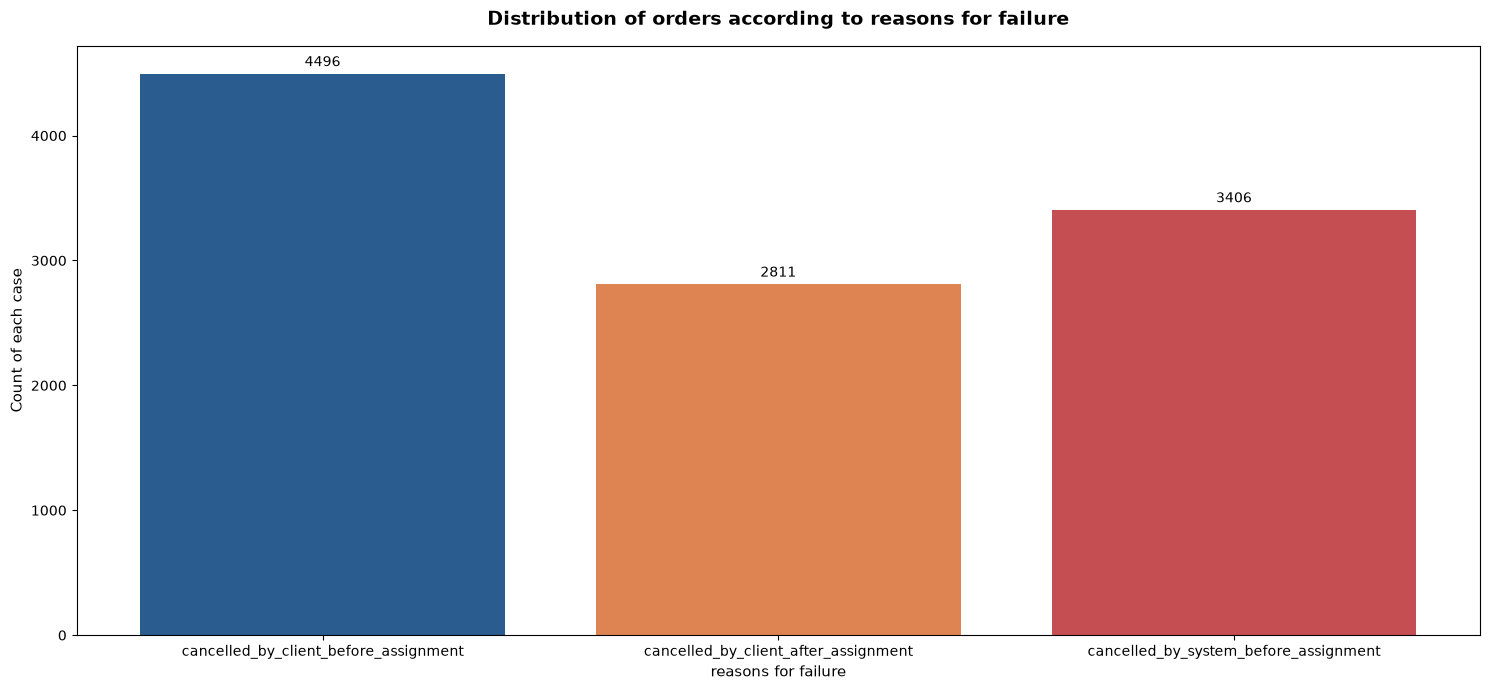

In [109]:
cancelled_by_client_before_assignment = df.loc[
                                                    (df['order_status_key']=='client cancelled') & 
                                                    (df['is_driver_assigned_key']=='not assigned')
                                                ]
cancelled_by_client_after_assignment = df.loc[
                                                    (df['order_status_key']=='client cancelled') & 
                                                    (df['is_driver_assigned_key']=='assigned')
                                                ]
cancelled_by_system_before_assignment = df.loc[
                                                    (df['order_status_key']=='system rejected') & 
                                                    (df['is_driver_assigned_key']=='not assigned')
                                                ]
cancelled_by_system_after_assignment = df.loc[
                                                    (df['order_status_key']=='system rejected') & 
                                                    (df['is_driver_assigned_key']=='assigned')
                                                ]


failure_distribution_df = pd.Series(
    {"cancelled_by_client_before_assignment":len(cancelled_by_client_before_assignment),
    "cancelled_by_client_after_assignment":len(cancelled_by_client_after_assignment),
    "cancelled_by_system_before_assignment":len(cancelled_by_system_before_assignment),
    }
)


plt.figure(figsize=(15,7))
bars = plt.bar(x=failure_distribution_df.index, height=failure_distribution_df.values, color=["#2b5c8f", "#DD8452", "#C44E52"])

plt.bar_label(bars, padding=3)
plt.title("Distribution of orders according to reasons for failure",fontsize=14, pad=15, fontweight='bold')
plt.xlabel("reasons for failure", fontsize=11)
plt.ylabel("Count of each case", fontsize=11)
plt.tight_layout()
plt.savefig("failure_reasons.png", dpi=150, bbox_inches='tight')
plt.show()